# **EDA**

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from xgboost import plot_tree
from xgboost import to_graphviz

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from tqdm import tqdm


In [3]:
df = pd.read_csv("BiomassDataSetProximate.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   biomass  78 non-null     object 
 1   VM       78 non-null     float64
 2   FC       78 non-null     float64
 3   ASH      78 non-null     float64
 4   C        78 non-null     float64
 5   H        78 non-null     float64
 6   O        78 non-null     float64
 7   N        78 non-null     float64
 8   S        78 non-null     float64
 9   HHV      78 non-null     float64
dtypes: float64(9), object(1)
memory usage: 6.2+ KB


In [5]:
df.head()

,biomass,VM,FC,ASH,C,H,O,N,S,HHV
0,alder-fir sawdust,76.6,19.2,4.2,50.9,5.84,38.5,0.5,0.04,19.949
1,balsam bark,77.4,20.0,2.6,52.6,6.04,38.5,0.2,0.10,20.597
2,beech bark,73.7,18.5,7.8,47.4,5.53,38.5,0.6,0.10,18.624
3,birch bark,78.5,19.4,2.1,55.8,6.56,35.0,0.5,0.10,21.865
4,Christmas trees,74.2,20.7,5.1,51.7,5.60,36.7,0.5,0.40,19.973


# DATA PREPROCCESING

In [6]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

In [7]:
numeric_cols = [
    'VM', 'FC', 'ASH',
    'C', 'H', 'O', 'N', 'S',
    'HHV'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nMissing Values Before:")
print(df[numeric_cols].isnull().sum())


Missing Values Before:
VM     0
FC     0
ASH    0
C      0
H      0
O      0
N      0
S      0
HHV    0
dtype: int64


In [8]:
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

if 'biomass' in df.columns:
    df['biomass'] = df['biomass'].fillna("unknown")
    df['biomass'] = df['biomass'].astype(str).str.strip()

for col in numeric_cols:
    df = df[df[col] >= 0]

In [9]:
df["total_composition"] = (
    df["C"] +
    df["H"] +
    df["O"] +
    df["N"] +
    df["S"] +
    df["ASH"]
)

print("\nComposition Statistics:")
print(df["total_composition"].describe())



Composition Statistics:
count     78.000000
mean     100.015641
std        0.043711
min       99.930000
25%       99.980000
50%      100.020000
75%      100.047500
max      100.120000
Name: total_composition, dtype: float64


In [10]:
df["efficiency"] = (df["VM"] + df["FC"]) / (df["ASH"] + 1e-6)


df["emission"] = df["N"] * 0.6 + df["S"] * 1.0 + df["O"] * 0.2

# FIT XGBOOST MODEL

In [11]:
X = df[["VM", "FC", "ASH", "C", "H", "O", "N", "S"]]

y = df[["HHV", "efficiency", "emission"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


base_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model = MultiOutputRegressor(base_model)


model.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [12]:
y_pred = model.predict(X_test)

for i, target in enumerate(["HHV", "efficiency", "emission"]):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"{target}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2 : {r2:.4f}")
    print("-" * 30)

HHV
  MSE: 0.2282
  R2 : 0.8765
------------------------------
efficiency
  MSE: 554.0076
  R2 : 0.8434
------------------------------
emission
  MSE: 0.1141
  R2 : 0.8596
------------------------------


performance space

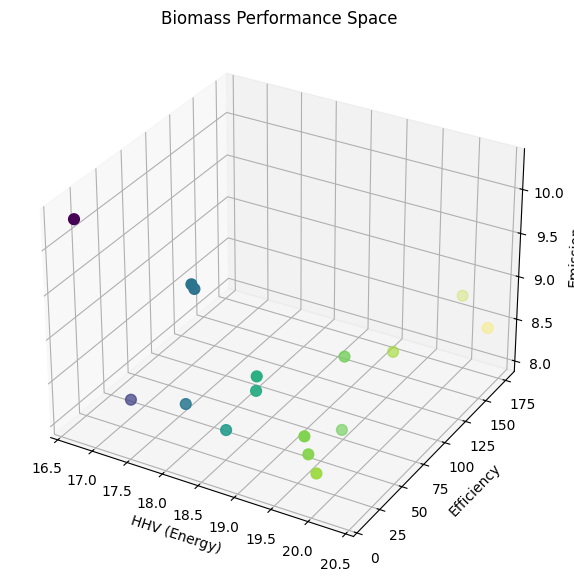

In [13]:
hhv = y_pred[:, 0]
eff = y_pred[:, 1]
emi = y_pred[:, 2]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(hhv, eff, emi, c=hhv, s=60)

ax.set_xlabel("HHV (Energy)")
ax.set_ylabel("Efficiency")
ax.set_zlabel("Emission")

ax.set_title("Biomass Performance Space")

plt.show()

interactive performance space

In [14]:
df_vis = pd.DataFrame({
    "HHV": hhv,
    "Efficiency": eff,
    "Emission": emi,
    "Biomass": df.loc[X_test.index, "biomass"]
})

fig = px.scatter_3d(
    df_vis,
    x="HHV",
    y="Efficiency",
    z="Emission",
    color="HHV",
    hover_name="Biomass",
    opacity=0.7
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    title="3D Biomass Performance"
)

fig.show()

predict existing data

In [ ]:
combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([y_train, y_test], axis=0)

y_pred = model.predict(combined)

for i, target in enumerate(["HHV", "efficiency", "emission"]):
    mse = mean_squared_error(y_combined.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_combined.iloc[:, i], y_pred[:, i])

    print(f"{target}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2 : {r2:.4f}")
    print("-" * 30)

In [ ]:
df_vis = pd.DataFrame({
    "HHV": hhv,
    "Efficiency": eff,
    "Emission": emi,
    "Biomass": df.loc[combined.index, "biomass"]
})

fig = px.scatter_3d(
    df_vis,
    x="HHV",
    y="Efficiency",
    z="Emission",
    color="HHV",
    hover_name="Biomass",
    opacity=0.7
)

fig.update_traces(marker=dict(size=5))

fig.update_layout(
    title="3D Biomass Performance"
)

fig.show()

In [ ]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    pd.DataFrame({
        "HHV": hhv,
        "Efficiency": eff,
        "Emission": emi
    })
)

scaled_df = pd.DataFrame(scaled, columns=["HHV", "Efficiency", "Emission"])

score = scaled_df["HHV"] + scaled_df["Efficiency"] - scaled_df["Emission"]

In [ ]:
df_rank = pd.DataFrame({
    "Biomass": df.loc[combined.index, "biomass"],
    "Score": score
}).sort_values(by="Score", ascending=False).head(10)

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(df_rank["Biomass"], df_rank["Score"])
plt.gca().invert_yaxis()

plt.xlabel("Score")
plt.ylabel("Biomass")
plt.title("Top 10 Biomass Candidates (Normalized Score)")

plt.tight_layout()
plt.show()

# GA MIXING

In [15]:
!pip install tqdm

In [16]:
def format_mixture(x, df, top_k=5):
    pairs = [(df.iloc[i]['biomass'], x[i]) for i in range(len(x))]
    pairs = sorted(pairs, key=lambda v: v[1], reverse=True)

    return ", ".join([f"{name}:{val*100:.1f}%" for name, val in pairs[:top_k]])

In [17]:
n = len(df)

VM_arr  = df['VM'].values
FC_arr  = df['FC'].values
ASH_arr = df['ASH'].values
C_arr   = df['C'].values
H_arr   = df['H'].values
O_arr   = df['O'].values
N_arr   = df['N'].values
S_arr   = df['S'].values

In [18]:
POP_SIZE = 80
GENERATIONS = 100
ELITE_SIZE = 10
MUTATION_RATE = 0.15

# sparse
population = np.random.dirichlet(np.ones(n) * 0.1, size=POP_SIZE)

In [19]:
def evaluate(pop):

    VM  = pop @ VM_arr
    FC  = pop @ FC_arr
    ASH = pop @ ASH_arr
    C   = pop @ C_arr
    H   = pop @ H_arr
    O   = pop @ O_arr
    N   = pop @ N_arr
    S   = pop @ S_arr

    features = np.column_stack([VM, FC, ASH, C, H, O, N, S])

    pred = model.predict(features)

    HHV = pred[:, 0]
    eff = pred[:, 1]
    emis = pred[:, 2]

    score = (
        1.0 * HHV
        - 2.0 * emis
        + 0.5 * eff
    )

    return score, HHV, eff, emis


In [20]:
history = []
pbar = tqdm(range(GENERATIONS), desc="GA Optimization")

for gen in pbar:

    scores, HHV, eff, emis = evaluate(population)
    for i in range(len(population)):
      history.append({
          'x': population[i],
          'HHV': HHV[i],
          'efficiency': eff[i],
          'emission': emis[i],
          'score': scores[i],
          'generation': gen
      })

    # sort
    idx = np.argsort(scores)[::-1]
    population = population[idx]
    scores = scores[idx]

    # update tqdm info
    pbar.set_postfix({
        "best_score": f"{scores[0]:.3f}",
        "HHV": f"{HHV[idx][0]:.2f}"
    })

    # elitism
    new_pop = population[:ELITE_SIZE].copy().tolist()

    # offspring
    while len(new_pop) < POP_SIZE:

        i1, i2 = np.random.randint(0, 20, 2)
        p1 = population[i1]
        p2 = population[i2]

        # crossover
        alpha = np.random.rand()
        child = alpha * p1 + (1 - alpha) * p2

        # mutation
        if np.random.rand() < MUTATION_RATE:
            noise = np.random.normal(0, 0.05, size=n)
            child = np.clip(child + noise, 0, None)

        # normalize
        if child.sum() == 0:
            child = np.random.dirichlet(np.ones(n))
        else:
            child = child / child.sum()

        new_pop.append(child)

    population = np.array(new_pop)

GA Optimization: 100%|██████████| 100/100 [00:02<00:00, 44.90it/s, best_score=32.429, HHV=19.96]


In [21]:
scores, HHV, eff, emis = evaluate(population)

best_idx = np.argmax(scores)
best_x = population[best_idx]

print("\n=== BEST MIXTURE ===")

pairs = [(df.iloc[i]['biomass'], best_x[i]) for i in range(n)]
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

for name, val in pairs[:5]:
    print(f"{name}: {val*100:.2f}%")

print("\n=== PERFORMANCE ===")
print("HHV:", HHV[best_idx])
print("Efficiency:", eff[best_idx])
print("Emission:", emis[best_idx])
print("Score:", scores[best_idx])


=== BEST MIXTURE ===
oak wood: 30.35%
spruce wood: 13.88%
walnut blows: 12.85%
willow: 4.32%
walnut hulls and blows: 3.86%

=== PERFORMANCE ===
HHV: 19.96157
Efficiency: 58.918022
Emission: 8.495871
Score: 32.42884


top best combination

In [22]:
final_results = []

for i in range(len(population)):
    final_results.append({
        'x': population[i],
        'HHV': HHV[i],
        'efficiency': eff[i],
        'emission': emis[i],
        'score': scores[i]
    })

final_df = pd.DataFrame(final_results)

# Rank (highest score = best)
final_df = final_df.sort_values(by='score', ascending=False).reset_index(drop=True)

In [23]:
final_df['mixture'] = final_df['x'].apply(lambda x: format_mixture(x, df, top_k=20))
# print(final_df[['score', 'HHV', 'efficiency', 'emission', 'mixture']])

final_df = (
    final_df
    .sort_values('score', ascending=False)
    .drop_duplicates(subset='mixture', keep='first')
    .reset_index(drop=True)
)

final_df[['mixture', 'HHV']]

,mixture,HHV
0,"oak wood:30.3%, spruce wood:13.9%, walnut blow...",19.961571
1,"oak wood:12.0%, spruce wood:8.7%, walnut blows...",19.805910
2,"oak wood:14.1%, walnut blows:8.7%, spruce wood...",19.649931
3,"oak wood:12.3%, spruce wood:4.4%, pine bark:4....",19.300165
4,"oak wood:13.5%, spruce wood:9.2%, walnut blows...",19.579193
5,"oak wood:12.5%, spruce wood:8.4%, wood-agricul...",19.437592
6,"oak wood:10.4%, spruce wood:5.7%, pine sawdust...",19.455797
7,"oak wood:15.5%, pine pruning:6.2%, balsam bark...",19.442505
8,"oak wood:9.3%, hazelnut shells:4.8%, currency ...",19.407616
9,"oak wood:11.6%, spruce wood:7.4%, walnut shell...",19.381851


all history combination

In [25]:
history_df=pd.DataFrame(history)

history_df['mixture'] = history_df['x'].apply(lambda x: format_mixture(x, df,top_k = 20))
history_df = history_df.sort_values(by='score', ascending=False).reset_index(drop=True)
history_df = history_df.drop_duplicates(subset='mixture', keep='first')

In [29]:
history_df[['mixture','score','HHV','efficiency','emission']]

,mixture,score,HHV,efficiency,emission
0,"oak wood:30.3%, spruce wood:13.9%, walnut blow...",32.428841,19.961571,58.918022,8.495871
305,"oak wood:29.7%, spruce wood:13.5%, walnut blow...",32.428841,19.961571,58.918022,8.495871
496,"oak wood:29.9%, spruce wood:13.6%, walnut blow...",32.428841,19.961571,58.918022,8.495871
582,"oak wood:30.4%, spruce wood:13.9%, walnut blow...",32.428841,19.961571,58.918022,8.495871
614,"oak wood:30.1%, spruce wood:13.7%, walnut blow...",32.428841,19.961571,58.918022,8.495871
...,...,...,...,...,...
7995,"barley straw:13.7%, corn straw:12.4%, wood-str...",8.823522,18.661585,15.767958,8.861021
7996,"eucalyptus bark:15.9%, currency shredded:11.7%...",8.742608,18.801689,15.799097,8.979315
7997,"pepper residue:19.9%, sunflower husks:15.7%, m...",8.474504,18.593569,16.470284,9.177103
7998,"eucalyptus bark:32.1%, reed canary grass:11.2%...",8.003543,18.635811,12.232431,8.374242


# EVALUATION & Visualization

XGBoost model interpretation

In [26]:
!pip install graphviz

Target 0


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning:

The `num_trees` parameter is deprecated, use `tree_idx` insetad. 



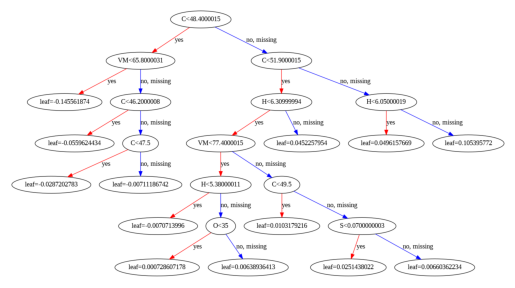

Target 1


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning:

The `num_trees` parameter is deprecated, use `tree_idx` insetad. 



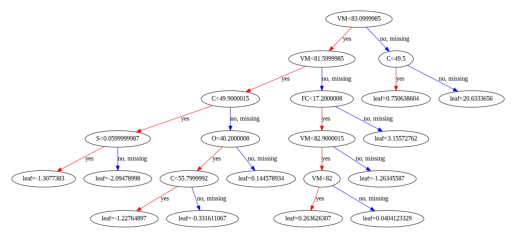

Target 2


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning:

The `num_trees` parameter is deprecated, use `tree_idx` insetad. 



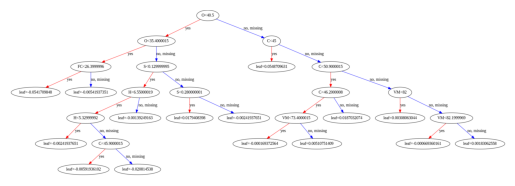

In [31]:
for i, xgb_model in enumerate(model.estimators_):
    print(f"Target {i}")

    plot_tree(xgb_model, num_trees=0)
    plt.show()

In [ ]:
for i, xgb_model in enumerate(model.estimators_):
    print(f"Target {i}")

    graph = to_graphviz(xgb_model, num_trees=0)
    graph.render(f"xgb_tree_{i}")
